<a href="https://colab.research.google.com/github/AnjaliKM-S/ICT-AKM_2026/blob/main/Case_study_Training_and_Evaluating_CNN_Models_on_CIFAR_100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import VGG16

from sklearn.metrics import classification_report

##Load CIFAR-100 Dataset

In [4]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


###Data Preprocessing

In [5]:
# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

###Display Sample Images

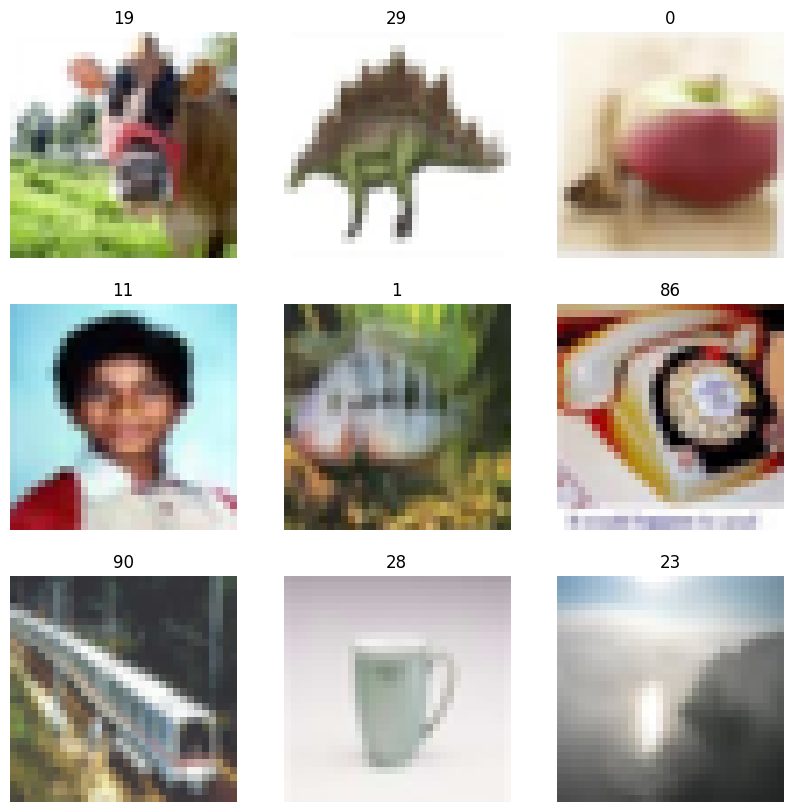

In [6]:
class_names = [str(i) for i in range(100)]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis("off")

plt.show()

###CUSTOM CNN MODEL
##Build Custom CNN Model

In [7]:
custom_model = Sequential()

# Block 1
custom_model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
    kernel_initializer='he_normal',
    kernel_regularizer=l2(0.001),
    input_shape=(32,32,3)
))
custom_model.add(BatchNormalization())

custom_model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
))
custom_model.add(BatchNormalization())

custom_model.add(MaxPooling2D((2,2)))
custom_model.add(Dropout(0.25))

# Block 2
custom_model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))
custom_model.add(BatchNormalization())

custom_model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))
custom_model.add(BatchNormalization())

custom_model.add(MaxPooling2D((2,2)))
custom_model.add(Dropout(0.3))

# Block 3
custom_model.add(Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
))
custom_model.add(BatchNormalization())

custom_model.add(MaxPooling2D((2,2)))
custom_model.add(Dropout(0.4))

# Dense Layers
custom_model.add(Flatten())

custom_model.add(Dense(
    256,
    activation='relu'
))
custom_model.add(Dropout(0.5))

custom_model.add(Dense(100, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


###Compile Custom CNN

In [8]:
custom_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
custom_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 690,948 (2.64 MB)

 Trainable params: 690,308 (2.63 MB)

 Non-trainable params: 640 (2.50 KB)

##Plot Custom CNN Architecture

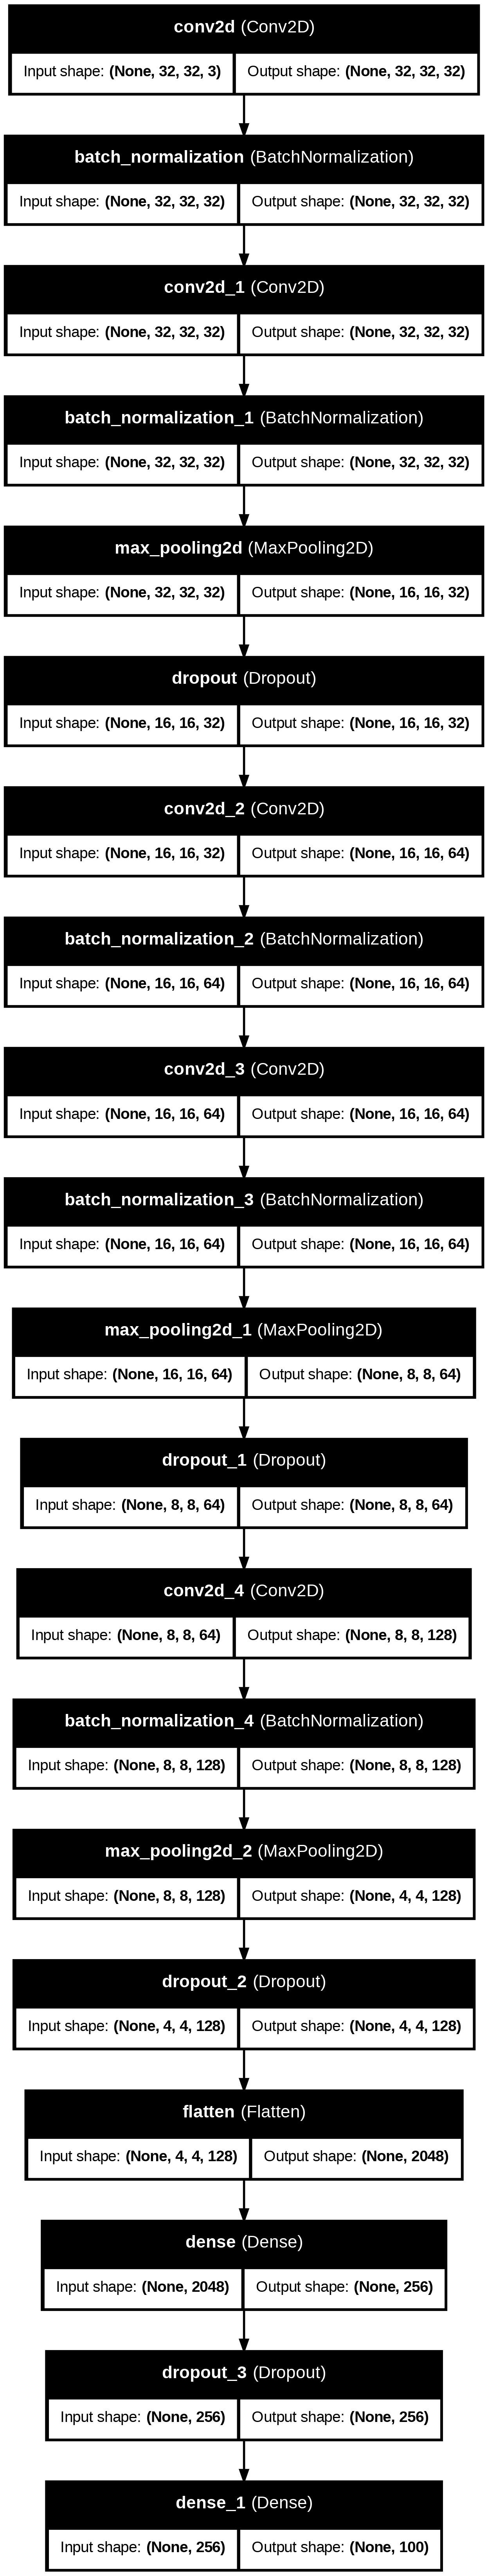

In [10]:
plot_model(
    custom_model,
    show_shapes=True,
    show_layer_names=True,
    to_file='custom_cnn.png'
)

###callbacks

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_custom_model.keras',
    save_best_only=True,
    monitor='val_accuracy'
)

####Train Custom CNN

In [12]:
history_custom = custom_model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.0351 - loss: 4.5291 - val_accuracy: 0.0747 - val_loss: 4.1916
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0610 - loss: 4.1946 - val_accuracy: 0.0838 - val_loss: 4.0422
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0880 - loss: 3.9824 - val_accuracy: 0.1559 - val_loss: 3.5941
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.1169 - loss: 3.7911 - val_accuracy: 0.1831 - val_loss: 3.4222
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.1408 - loss: 3.6049 - val_accuracy: 0.2281 - val_loss: 3.1837
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.1733 - loss: 3.4356 - val_accuracy: 0.2472 - val_loss: 3.1893
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.1956 - loss: 3.2916 - val_accuracy: 0.2735 - val_loss: 2.9372
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2231 - loss: 3.1389 - val_accuracy: 

In [23]:
#Evaluate CNN
custom_loss, custom_acc = custom_model.evaluate(x_test, y_test)

print("Custom CNN Accuracy:", custom_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5259 - loss: 1.7801
Custom CNN Accuracy: 0.5259000062942505


##VGG16 MODEL
#### Pretrained VGG16 Base

In [13]:
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

vgg_base.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


####Build VGG16 Model

In [14]:
vgg_model = Sequential([
    vgg_base,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(100, activation='softmax')
])

In [15]:
#compile VGG16
vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

####VGG16 Summary

In [16]:
vgg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,871,716 (56.73 MB)

 Trainable params: 157,028 (613.39 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

####Plot VGG16 Architecture

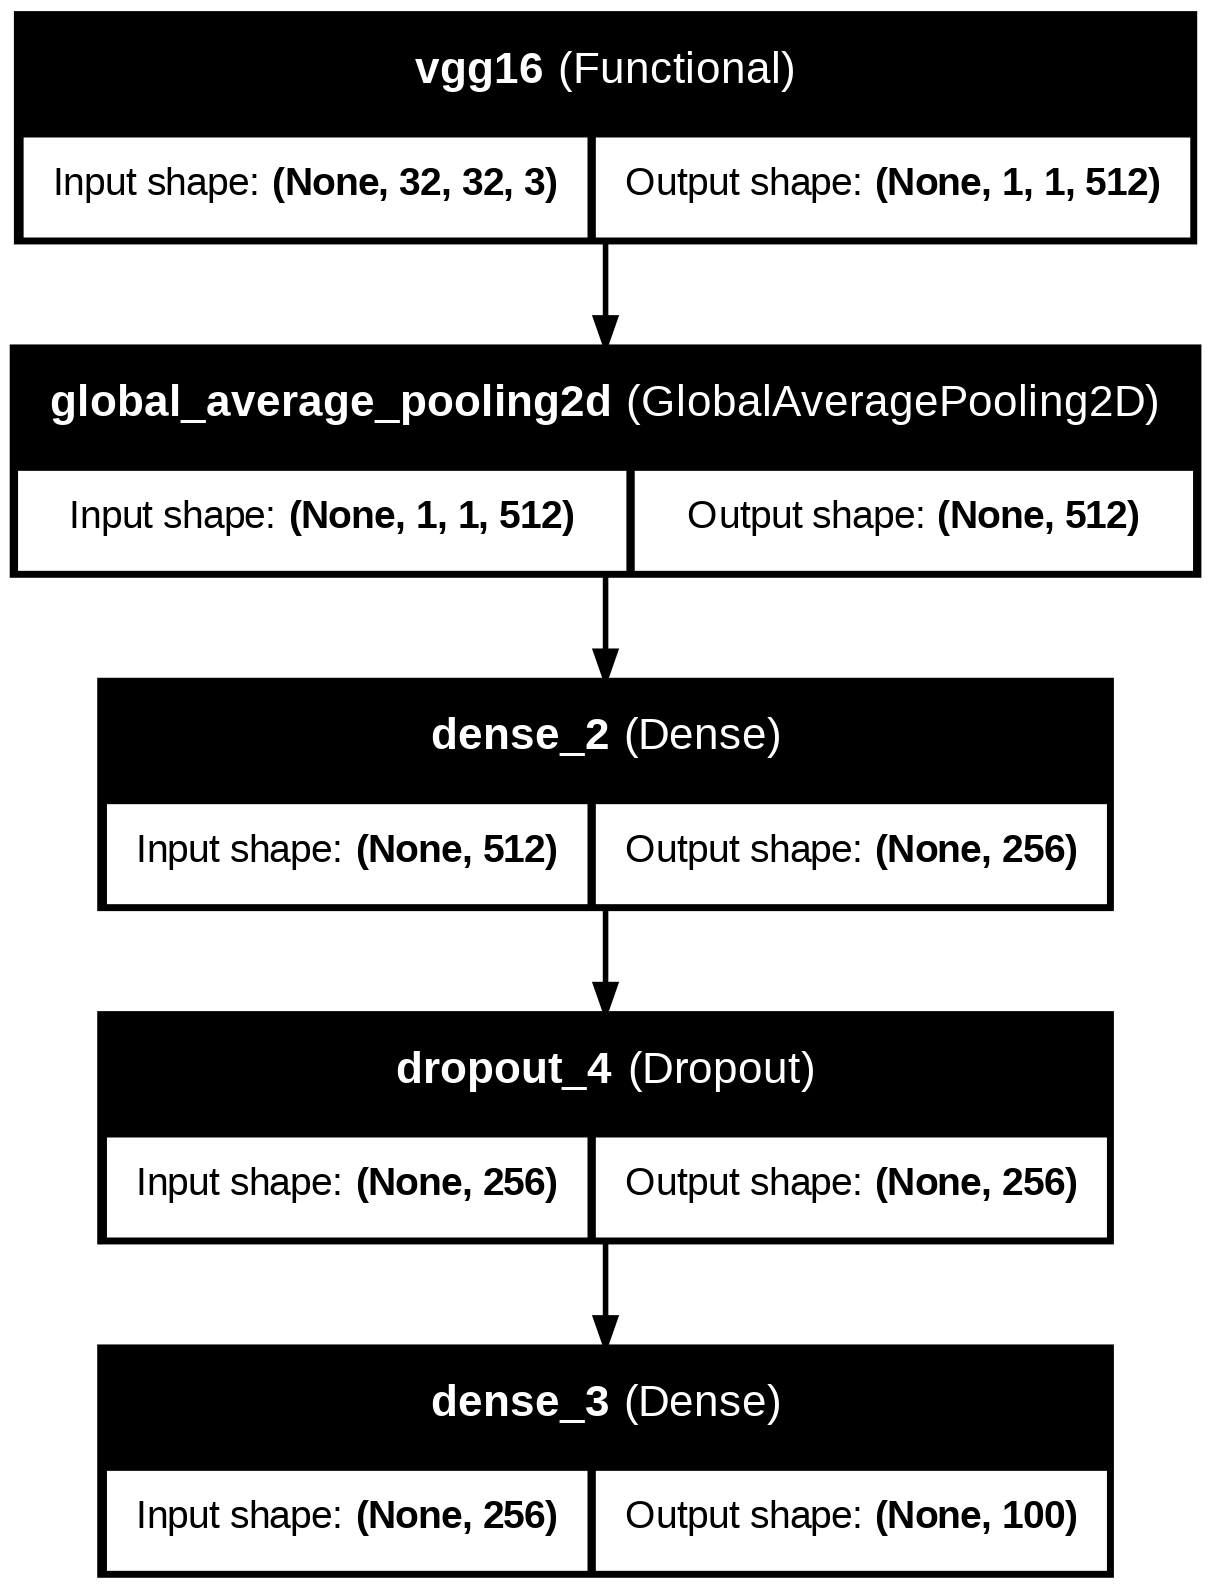

In [17]:
plot_model(
    vgg_model,
    show_shapes=True,
    show_layer_names=True,
    to_file='vgg16_model.png'
)

####Train VGG16

In [18]:
history_vgg = vgg_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.1420 - loss: 3.7349 - val_accuracy: 0.2479 - val_loss: 3.1401
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.2283 - loss: 3.1723 - val_accuracy: 0.2803 - val_loss: 2.9366
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.2612 - loss: 3.0030 - val_accuracy: 0.2965 - val_loss: 2.8468
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.2795 - loss: 2.9045 - val_accuracy: 0.3114 - val_loss: 2.7784
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.2921 - loss: 2.8326 - val_accuracy: 0.3176 - val_loss: 2.7441


##Evaluate VGG16

In [19]:
vgg_loss, vgg_acc = vgg_model.evaluate(x_test, y_test)

print("VGG16 Accuracy:", vgg_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2518 - loss: 3.1202
VGG16 Accuracy: 0.251800000667572


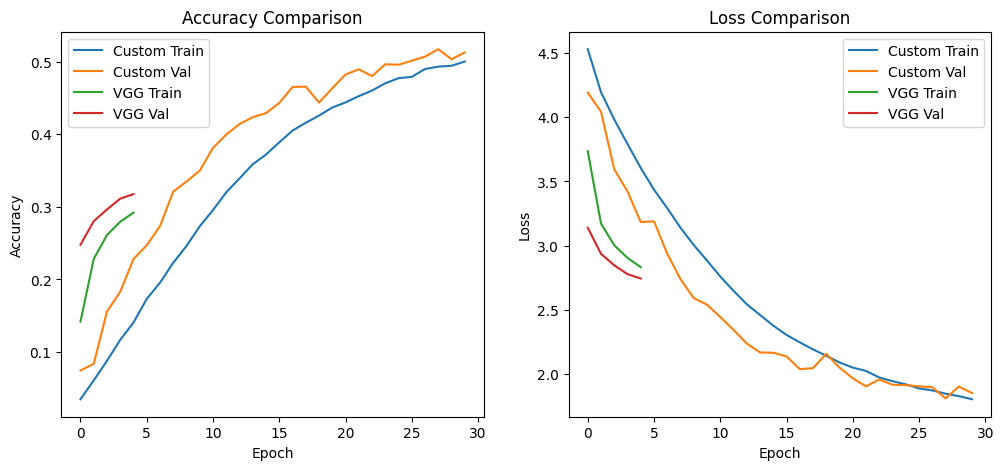

In [20]:
##Plot Accuracy Curves
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(history_custom.history['accuracy'], label='Custom Train')
plt.plot(history_custom.history['val_accuracy'], label='Custom Val')

plt.plot(history_vgg.history['accuracy'], label='VGG Train')
plt.plot(history_vgg.history['val_accuracy'], label='VGG Val')

plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)

plt.plot(history_custom.history['loss'], label='Custom Train')
plt.plot(history_custom.history['val_loss'], label='Custom Val')

plt.plot(history_vgg.history['loss'], label='VGG Train')
plt.plot(history_vgg.history['val_loss'], label='VGG Val')

plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

###Final Accuracy Comparison Table

In [24]:
print("\nFinal Accuracy Comparison")

print("----------------------------------")
print(f"Custom CNN Accuracy : {custom_acc:.4f}")
print(f"VGG16 Accuracy      : {vgg_acc:.4f}")
print("----------------------------------")


Final Accuracy Comparison
----------------------------------
Custom CNN Accuracy : 0.5259
VGG16 Accuracy      : 0.2518
----------------------------------


###Save Models

In [25]:
custom_model.save("custom_cnn_model.keras")
vgg_model.save("vgg16_cifar100_model.keras")